In [132]:
import pandas as pd
import numpy as np
# 读取CSV文件
df_apple = pd.read_csv("688981_posts_data.csv")


In [133]:
# 所有时间都是 2025 年的
df_apple['Date'] = "2025-" + df_apple['Date']
df_apple['Date'] = pd.to_datetime(df_apple['Date']).dt.date 
# df_apple['Date'] = pd.to_datetime(df_apple['Date'], format="%Y-%m-%d %H:%M")
df_apple.head()

,read_count,title,Date
0,13546,A股进口替代50强出炉,2025-05-02
1,188,"一起举报那个""满融满仓中芯国际""，刷屏可耻，把他封了",2025-05-07
2,116,明天的一季度业绩不知道什么样子,2025-05-07
3,1042,去年以来已经涨的够多了，现可以离场了，大盘上20天线中芯跌破20天线，君子不立危,2025-04-25
4,18,+2%收盘，明天可以起飞了,2025-05-07


In [134]:
import pandas as pd
import re



# 简单清洗文本（去除特殊符号、空格等）
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', str(text))  # 去除非字母数字字符
    text = text.strip()  # 去除首尾空格
    return text

df_apple["title"] = df_apple["title"].apply(clean_text)

print(df_apple.head())  # 检查清洗后的数据

   read_count                                  title        Date
0       13546                            A股进口替代50强出炉  2025-05-02
1         188                 一起举报那个满融满仓中芯国际刷屏可耻把他封了  2025-05-07
2         116                        明天的一季度业绩不知道什么样子  2025-05-07
3        1042  去年以来已经涨的够多了现可以离场了大盘上20天线中芯跌破20天线君子不立危  2025-04-25
4          18                             2收盘明天可以起飞了  2025-05-07


In [135]:
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

# 使用专为中文设计的情感分析模型
model_name = "yiyanghkust/finbert-tone-chinese"  # 金融情感分析模型
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# 创建中文情感分析pipeline
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# 分析中文文本
results_apple = []
for tweet in df_apple["title"]:
    try:
        sentiment = sentiment_pipeline(tweet)[0]
        # 转换标签格式以匹配后续处理代码
        # 这个模型的标签是 "positive" 和 "negative"
        results_apple.append((tweet, [sentiment]))
    except Exception as e:
        # 处理可能的错误，比如文本太长或格式问题
        print(f"处理文本时出错: {tweet}")
        print(e)
        results_apple.append((tweet, [{"label": "neutral", "score": 0.5}]))

results_apple
# ~2min

Device set to use cuda:0


[('A股进口替代50强出炉', [{'label': 'Neutral', 'score': 0.9952408075332642}]),
 ('一起举报那个满融满仓中芯国际刷屏可耻把他封了',
  [{'label': 'Neutral', 'score': 0.9937096834182739}]),
 ('明天的一季度业绩不知道什么样子', [{'label': 'Neutral', 'score': 0.6076997518539429}]),
 ('去年以来已经涨的够多了现可以离场了大盘上20天线中芯跌破20天线君子不立危',
  [{'label': 'Positive', 'score': 0.796721339225769}]),
 ('2收盘明天可以起飞了', [{'label': 'Neutral', 'score': 0.9914097189903259}]),
 ('满融满仓中芯国际是托大家一起举报', [{'label': 'Neutral', 'score': 0.9962316155433655}]),
 ('港股不起来他一辈子不会动', [{'label': 'Neutral', 'score': 0.9869755506515503}]),
 ('一季报看着有问题了', [{'label': 'Negative', 'score': 0.9805811643600464}]),
 ('前天收盘前没买到赤峰黄金今天转战抄底拉升鹏欣资源必须封板',
  [{'label': 'Neutral', 'score': 0.9973517656326294}]),
 ('中芯阴跌不止大家还坚守吗', [{'label': 'Negative', 'score': 0.7802782654762268}]),
 ('股', [{'label': 'Neutral', 'score': 0.9794074296951294}]),
 ('欢迎大主播陆老割进场', [{'label': 'Neutral', 'score': 0.9928905963897705}]),
 ('你们有谁在108元买的我在108买的现在补又不想补割肯定不割了耐心等待等',
  [{'label': 'Neutral', 'score': 0.991073310375

In [136]:
final_scores = []
for result in results_apple:
    sentiment = result[1][0]
    label = sentiment["label"]
    score = sentiment["score"]

    # LABEL_0: Negative
    # LABEL_1: Neutral
    # LABEL_2: Positive
    if label == "Positive":
        final_scores.append(score)
    elif label == "Negative":
        final_scores.append(-1*score)
    else:
        final_scores.append(0)
df_apple.loc[:,"score"] = final_scores
df_apple

,read_count,title,Date,score
0,13546,A股进口替代50强出炉,2025-05-02,0.000000
1,188,一起举报那个满融满仓中芯国际刷屏可耻把他封了,2025-05-07,0.000000
2,116,明天的一季度业绩不知道什么样子,2025-05-07,0.000000
3,1042,去年以来已经涨的够多了现可以离场了大盘上20天线中芯跌破20天线君子不立危,2025-04-25,0.796721
4,18,2收盘明天可以起飞了,2025-05-07,0.000000
...,...,...,...,...
530,8418,5180亿元主力资金今日撤离电子板块,2025-04-14,0.000000
531,206,中芯国际各种基金繁多现在都是存量资金博弈赎回压力大减持和做空成首选涨不上,2025-04-14,-0.908147
532,161,垃圾到无以复加割肉走人两天亏65万加入黑名单再也不买,2025-04-14,0.000000
533,359,按照美豁免清单中芯国际对美出口的集成电路在里边吗,2025-04-13,0.000000


In [137]:
import pandas as pd

# 假设df_apple是您已有的DataFrame（如图片所示）
# 包含列：read_count, title, Date, score（初始全为0.0）

# 2. 将分数赋值给DataFrame（修正图片中的拼写错误）
df_apple.loc[:, "score"] = final_scores  # 原图片代码有拼写错误(df APPLE,locL::"score"])

# 3. 计算每日加权平均分（按阅读量加权）
# 首先确保日期格式正确
df_apple["Date"] = pd.to_datetime(df_apple["Date"]).dt.date

# 计算加权分数
df_apple["weighted_score"] = df_apple["score"] * df_apple["read_count"]

# 按日期分组计算加权平均
daily_avg = df_apple.groupby("Date").apply(
    lambda x: x["weighted_score"].sum() / x["read_count"].sum() if x["read_count"].sum() > 0 else 0
).reset_index(name="score")

# 4. 输出结果
print("每日加权平均分：")
print(daily_avg)

# 可选：保存结果
daily_avg.to_csv("daily_weighted_scores.csv", index=False)

每日加权平均分：
          Date     score
0   2025-02-09  0.997773
1   2025-02-11  0.000000
2   2025-02-14  0.998067
3   2025-02-18  0.997005
4   2025-02-19  0.814396
5   2025-03-13 -0.780278
6   2025-03-27  0.000000
7   2025-03-28  0.000000
8   2025-03-29  0.000000
9   2025-03-31  0.000000
10  2025-04-01  0.000000
11  2025-04-09  0.000000
12  2025-04-11  0.420114
13  2025-04-13  0.000000
14  2025-04-14 -0.003737
15  2025-04-15 -0.636076
16  2025-04-16  0.022404
17  2025-04-17  0.183457
18  2025-04-18  0.014265
19  2025-04-19  0.608287
20  2025-04-20  0.492090
21  2025-04-21  0.234639
22  2025-04-22 -0.216974
23  2025-04-23  0.058991
24  2025-04-24  0.059754
25  2025-04-25  0.048608
26  2025-04-26  0.000000
27  2025-04-27 -0.191797
28  2025-04-28 -0.301251
29  2025-04-29 -0.065141
30  2025-04-30  0.048551
31  2025-05-01 -0.480477
32  2025-05-02  0.000000
33  2025-05-03  0.213719
34  2025-05-04  0.000000
35  2025-05-05  0.000000
36  2025-05-06  0.004948
37  2025-05-07  0.000114


C:\Users\liuyu\AppData\Local\Temp\ipykernel_13876\707320577.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_avg = df_apple.groupby("Date").apply(


In [138]:
df_apple.describe()

,read_count,score,weighted_score
count,535.000000,535.000000,535.000000
mean,1996.867290,0.052797,77.995732
std,6823.991233,0.369332,2217.064342
min,17.000000,-0.998594,-26246.928767
25%,139.000000,0.000000,0.000000
50%,258.000000,0.000000,0.000000
75%,633.000000,0.000000,0.000000
max,88714.000000,0.998958,15462.115899


In [139]:
# pip install akshare --upgrade

In [140]:
import akshare as ak

# 使用 akshare 获取中芯国际 688981 历史数据

data = ak.stock_zh_a_hist(symbol="688981", period="daily", start_date="20250209", end_date="20250507")

# 数据处理
data = data.rename(columns={
    "日期": "Date",
    "收盘": "close",
})[["Date", "close"]]  # 只保留这两列

print(data.head())


         Date   close
0  2025-02-10  103.85
1  2025-02-11  100.86
2  2025-02-12  104.32
3  2025-02-13  101.11
4  2025-02-14   99.08


In [141]:
# %pip install tensorflow
# %pip install scikit-learn

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# 将值数组转换为数据集矩阵
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        dataX.append(dataset[i:(i+look_back), :])
        dataY.append(dataset[i + look_back, 0])  # 我们只预测收盘价
    return np.array(dataX), np.array(dataY)

# # 创建模拟数据
# dates = pd.date_range(start='2025-02-08', periods=90, freq='D')
# np.random.seed(42)
# scores = np.random.uniform(-1, 1, size=90)
# closes = 100 + np.cumsum(np.random.normal(0, 1, 90))

# daily_avg = pd.DataFrame({'Date': dates, 'score': scores})

# 补全缺失日期,以data的日期为准
daily_avg['Date'] = pd.to_datetime(daily_avg['Date'])
data['Date'] = pd.to_datetime(data['Date'])
daily_avg = daily_avg.set_index('Date').reindex(data['Date']).reset_index()

# 对缺失score的日期插值
daily_avg['score'] = daily_avg['score'].interpolate(method='linear')
daily_avg['score'] = daily_avg['score'].fillna(0)  # 如果需要填充缺失值为0

# 将日期转换为字符串格式
daily_avg['Date'] = daily_avg['Date'].dt.strftime('%Y-%m-%d')
data['Date'] = data['Date'].dt.strftime('%Y-%m-%d')
# print(daily_avg)
print(data)

# 合并两个数据集
merged_data = pd.merge(daily_avg, data, on='Date')
merged_data.set_index('Date', inplace=True)
# print(merged_data)

# 添加sentiment特征工程
merged_data['score_lag1'] = merged_data['score'].shift(1)  # 前一天的情绪分数
merged_data['score_ma3'] = merged_data['score'].rolling(window=3).mean()  # 3天平均情绪
merged_data['score_ma5'] = merged_data['score'].rolling(window=5).mean()  # 5天平均情绪

# 删除NaN值
merged_data = merged_data.dropna()

# 选择特征 - 收盘价和所有情绪相关特征
features = ['close', 'score_ma5']
dataset = merged_data[features].values.astype('float32')

# 规范化数据集
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# 分割为训练集和测试集
train_size = int(len(dataset_scaled) * 0.67)
test_size = len(dataset_scaled) - train_size
train, test = dataset_scaled[0:train_size,:], dataset_scaled[train_size:len(dataset_scaled),:]

# 重新整形为 X=t 和 Y=t+1
look_back = 3  # 使用5天的历史数据来预测下一天
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# 注意: 这里不需要reshape，因为create_dataset已经返回正确的形状
# 输入形状为 [样本数, 时间步长, 特征数]

# 创建并拟合LSTM网络
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, 2)))  # 2个特征: close和score
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=16, verbose=2)

# 进行预测
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# 为了反归一化，我们需要构建完整的scaler输入形状
# 因为我们有2个特征，但只预测了1个

# 创建占位数组用于反归一化
trainY_reshaped = np.zeros((len(trainY), 2))
trainY_reshaped[:,0] = trainY
trainY_reshaped[:,1] = train[:len(trainY), 1]

testY_reshaped = np.zeros((len(testY), 2))
testY_reshaped[:,0] = testY
testY_reshaped[:,1] = test[:len(testY), 1]

trainPredict_reshaped = np.zeros((len(trainPredict), 2))
trainPredict_reshaped[:,0] = trainPredict[:,0]
trainPredict_reshaped[:,1] = train[:len(trainPredict), 1]

testPredict_reshaped = np.zeros((len(testPredict), 2))
testPredict_reshaped[:,0] = testPredict[:,0]
testPredict_reshaped[:,1] = test[:len(testPredict), 1]

# 反归一化
trainPredict = scaler.inverse_transform(trainPredict_reshaped)[:,0]
trainY = scaler.inverse_transform(trainY_reshaped)[:,0]
testPredict = scaler.inverse_transform(testPredict_reshaped)[:,0]
testY = scaler.inverse_transform(testY_reshaped)[:,0]

# # 计算均方根误差
# trainScore = np.sqrt(mean_squared_error(trainY, trainPredict))
# print('训练集得分: %.2f RMSE' % (trainScore))
# testScore = np.sqrt(mean_squared_error(testY, testPredict))
# print('测试集得分: %.2f RMSE' % (testScore))

# # 准备绘图数据
# # 首先反归一化整个数据集
# dataset_inv = scaler.inverse_transform(dataset_scaled)
# actual_close = dataset_inv[:,0]

# # 创建预测结果的完整序列
# trainPredictPlot = np.empty_like(actual_close)
# trainPredictPlot[:] = np.nan
# trainPredictPlot[look_back:look_back+len(trainPredict)] = trainPredict

# testPredictPlot = np.empty_like(actual_close)
# testPredictPlot[:] = np.nan
# testPredictPlot[len(trainPredict)+(look_back*2)+1:len(actual_close)-1] = testPredict

# # 绘制基线和预测结果
# plt.figure(figsize=(12,6))
# plt.plot(actual_close, label='实际价格')
# plt.plot(trainPredictPlot, label='训练集预测')
# plt.plot(testPredictPlot, label='测试集预测')
# plt.title('股票价格预测')
# plt.xlabel('时间')
# plt.ylabel('价格')
# plt.legend()
# plt.show()

          Date   close
0   2025-02-10  103.85
1   2025-02-11  100.86
2   2025-02-12  104.32
3   2025-02-13  101.11
4   2025-02-14   99.08
5   2025-02-17  101.00
6   2025-02-18   98.28
7   2025-02-19  101.94
8   2025-02-20   99.21
9   2025-02-21  103.98
10  2025-02-24  103.40
11  2025-02-25  101.28
12  2025-02-26  104.00
13  2025-02-27  102.44
14  2025-02-28   97.79
15  2025-03-03   96.00
16  2025-03-04   97.28
17  2025-03-05   97.57
18  2025-03-06   98.66
19  2025-03-07   96.88
20  2025-03-10   95.66
21  2025-03-11   96.12
22  2025-03-12   95.90
23  2025-03-13   92.98
24  2025-03-14   94.81
25  2025-03-17   93.37
26  2025-03-18   94.10
27  2025-03-19   93.75
28  2025-03-20   93.27
29  2025-03-21   91.20
30  2025-03-24   91.45
31  2025-03-25   89.87
32  2025-03-26   90.00
33  2025-03-27   92.47
34  2025-03-28   90.40
35  2025-03-31   89.33
36  2025-04-01   86.50
37  2025-04-02   86.85
38  2025-04-03   88.09
39  2025-04-07   84.00
40  2025-04-08   85.00
41  2025-04-09   90.18
42  2025-04

d:\ana\envs\d2l\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 - 1s - 623ms/step - loss: 0.3525
Epoch 2/100
2/2 - 0s - 34ms/step - loss: 0.3149
Epoch 3/100
2/2 - 0s - 28ms/step - loss: 0.2800
Epoch 4/100
2/2 - 0s - 31ms/step - loss: 0.2476
Epoch 5/100
2/2 - 0s - 29ms/step - loss: 0.2186
Epoch 6/100
2/2 - 0s - 70ms/step - loss: 0.1894
Epoch 7/100
2/2 - 0s - 21ms/step - loss: 0.1624
Epoch 8/100
2/2 - 0s - 29ms/step - loss: 0.1417
Epoch 9/100
2/2 - 0s - 27ms/step - loss: 0.1163
Epoch 10/100
2/2 - 0s - 24ms/step - loss: 0.0971
Epoch 11/100
2/2 - 0s - 28ms/step - loss: 0.0784
Epoch 12/100
2/2 - 0s - 27ms/step - loss: 0.0625
Epoch 13/100
2/2 - 0s - 25ms/step - loss: 0.0483
Epoch 14/100
2/2 - 0s - 30ms/step - loss: 0.0357
Epoch 15/100
2/2 - 0s - 31ms/step - loss: 0.0267
Epoch 16/100
2/2 - 0s - 33ms/step - loss: 0.0209
Epoch 17/100
2/2 - 0s - 34ms/step - loss: 0.0152
Epoch 18/100
2/2 - 0s - 27ms/step - loss: 0.0132
Epoch 19/100
2/2 - 0s - 29ms/step - loss: 0.0131
Epoch 20/100
2/2 - 0s - 27ms/step - loss: 0.0146
Epoch 21/100
2/2 - 0s - 24ms/step - loss

In [166]:
# 计算均方根误差
print("训练集得分: %.2f RMSE" % (np.sqrt(mean_squared_error(trainY, trainPredict))))
print("测试集得分: %.2f RMSE" % (np.sqrt(mean_squared_error(testY, testPredict))))

# 准备绘图数据
# 首先反归一化整个数据集
dataset_inv = scaler.inverse_transform(dataset_scaled)
actual_close = dataset_inv[:,0]

# 创建预测结果的完整序列
trainPredictPlot = np.empty_like(actual_close)
trainPredictPlot[:] = np.nan
trainPredictPlot[look_back:look_back+len(trainPredict)] = trainPredict

testPredictPlot = np.empty_like(actual_close)
testPredictPlot[:] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(actual_close)-1] = testPredict

训练集得分: 2.05 RMSE
测试集得分: 1.78 RMSE


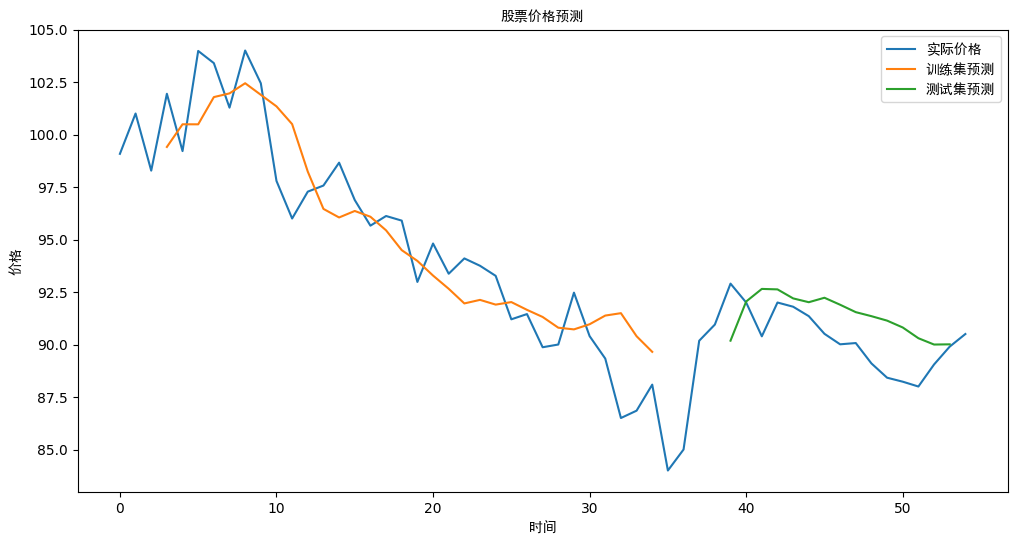

In [167]:
from matplotlib.font_manager import FontProperties

#windows字体
font = FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows中文黑体
# font = FontProperties(fname='/System/Library/Fonts/STHeiti Medium.ttc')  # macOS中文黑体


# 绘制基线和预测结果
plt.figure(figsize=(12,6))
plt.plot(actual_close, label='实际价格')
plt.plot(trainPredictPlot, label='训练集预测')
plt.plot(testPredictPlot, label='测试集预测')
plt.title('股票价格预测', fontproperties=font)
plt.xlabel('时间', fontproperties=font)
plt.ylabel('价格', fontproperties=font)
# plt.legend()
plt.legend(prop=font) 
plt.show()

In [168]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# # 将值数组转换为数据集矩阵
# def create_dataset(dataset, look_back=1):
#     dataX, dataY = [], []
#     for i in range(len(dataset)-look_back-1):
#         dataX.append(dataset[i:(i+look_back), :])
#         dataY.append(dataset[i + look_back, 0])  # 我们只预测收盘价
#     return np.array(dataX), np.array(dataY)

# # 固定随机种子以便复现
# tf.random.set_seed(7)

# # # 创建模拟数据
# # dates = pd.date_range(start='2025-02-01', periods=90, freq='D')
# # np.random.seed(42)
# # closes = 100 + np.cumsum(np.random.normal(0, 1, 90))

# data = pd.DataFrame({'Date': dates, 'close': closes})
# data.set_index('Date', inplace=True)

# 选择特征 - 只有收盘价
dataset = data[['close']].values.astype('float32')

# 规范化数据集
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# 分割为训练集和测试集
train_size = int(len(dataset_scaled) * 0.67)
test_size = len(dataset_scaled) - train_size
train, test = dataset_scaled[0:train_size,:], dataset_scaled[train_size:len(dataset_scaled),:]

# 重新整形为 X=t 和 Y=t+1
look_back = 3  # 使用5天的历史数据来预测下一天
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# 创建并拟合LSTM网络
model = Sequential()
model.add(LSTM(50, input_shape=(look_back, 1)))  # 1个特征: close
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=16, verbose=2)

# 进行预测
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# 反归一化
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

# 计算均方根误差
trainScore = np.sqrt(mean_squared_error(trainY, trainPredict))
print('训练集得分: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY, testPredict))
print('测试集得分: %.2f RMSE' % (testScore))



Epoch 1/100


d:\ana\envs\d2l\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 - 2s - 537ms/step - loss: 0.3535
Epoch 2/100
3/3 - 0s - 21ms/step - loss: 0.3049
Epoch 3/100
3/3 - 0s - 19ms/step - loss: 0.2577
Epoch 4/100
3/3 - 0s - 18ms/step - loss: 0.2165
Epoch 5/100
3/3 - 0s - 22ms/step - loss: 0.1752
Epoch 6/100
3/3 - 0s - 23ms/step - loss: 0.1415
Epoch 7/100
3/3 - 0s - 22ms/step - loss: 0.1086
Epoch 8/100
3/3 - 0s - 20ms/step - loss: 0.0808
Epoch 9/100
3/3 - 0s - 20ms/step - loss: 0.0551
Epoch 10/100
3/3 - 0s - 20ms/step - loss: 0.0374
Epoch 11/100
3/3 - 0s - 19ms/step - loss: 0.0249
Epoch 12/100
3/3 - 0s - 23ms/step - loss: 0.0186
Epoch 13/100
3/3 - 0s - 23ms/step - loss: 0.0177
Epoch 14/100
3/3 - 0s - 19ms/step - loss: 0.0194
Epoch 15/100
3/3 - 0s - 19ms/step - loss: 0.0218
Epoch 16/100
3/3 - 0s - 20ms/step - loss: 0.0226
Epoch 17/100
3/3 - 0s - 19ms/step - loss: 0.0218
Epoch 18/100
3/3 - 0s - 18ms/step - loss: 0.0201
Epoch 19/100
3/3 - 0s - 18ms/step - loss: 0.0188
Epoch 20/100
3/3 - 0s - 18ms/step - loss: 0.0175
Epoch 21/100
3/3 - 0s - 23ms/step - loss

In [169]:
# 计算均方根误差
trainScore = np.sqrt(mean_squared_error(trainY, trainPredict))
print('训练集得分: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY, testPredict))
print('测试集得分: %.2f RMSE' % (testScore))

# 准备绘图数据
dataset_inv = scaler.inverse_transform(dataset_scaled)
actual_close = dataset_inv[:,0]

# 创建预测结果的完整序列
trainPredictPlot = np.empty_like(actual_close)
trainPredictPlot[:] = np.nan
trainPredictPlot[look_back:look_back+len(trainPredict)] = trainPredict[:,0]

testPredictPlot = np.empty_like(actual_close)
testPredictPlot[:] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(actual_close)-1] = testPredict[:,0]

训练集得分: 2.09 RMSE
测试集得分: 1.82 RMSE


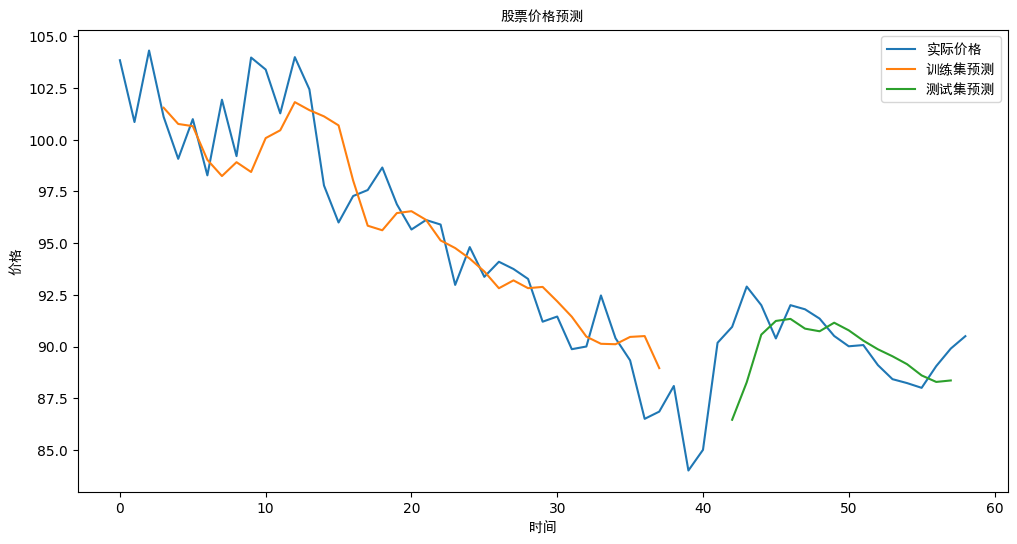

In [170]:
from matplotlib.font_manager import FontProperties

#字体
# font = FontProperties(fname='/System/Library/Fonts/STHeiti Medium.ttc')  # macOS中文黑体
font = FontProperties(fname='C:/Windows/Fonts/simhei.ttf')  # Windows中文黑体

# 绘制基线和预测结果
plt.figure(figsize=(12,6))
plt.plot(actual_close, label='实际价格')
plt.plot(trainPredictPlot, label='训练集预测')
plt.plot(testPredictPlot, label='测试集预测')
plt.title('股票价格预测', fontproperties=font)
plt.xlabel('时间', fontproperties=font)
plt.ylabel('价格', fontproperties=font)
# plt.legend()
plt.legend(prop=font) 
plt.show()

训练集RMSE: 2.09 vs 测试集RMSE: 1.82
测试集比训练集性能提升了: 12.61%


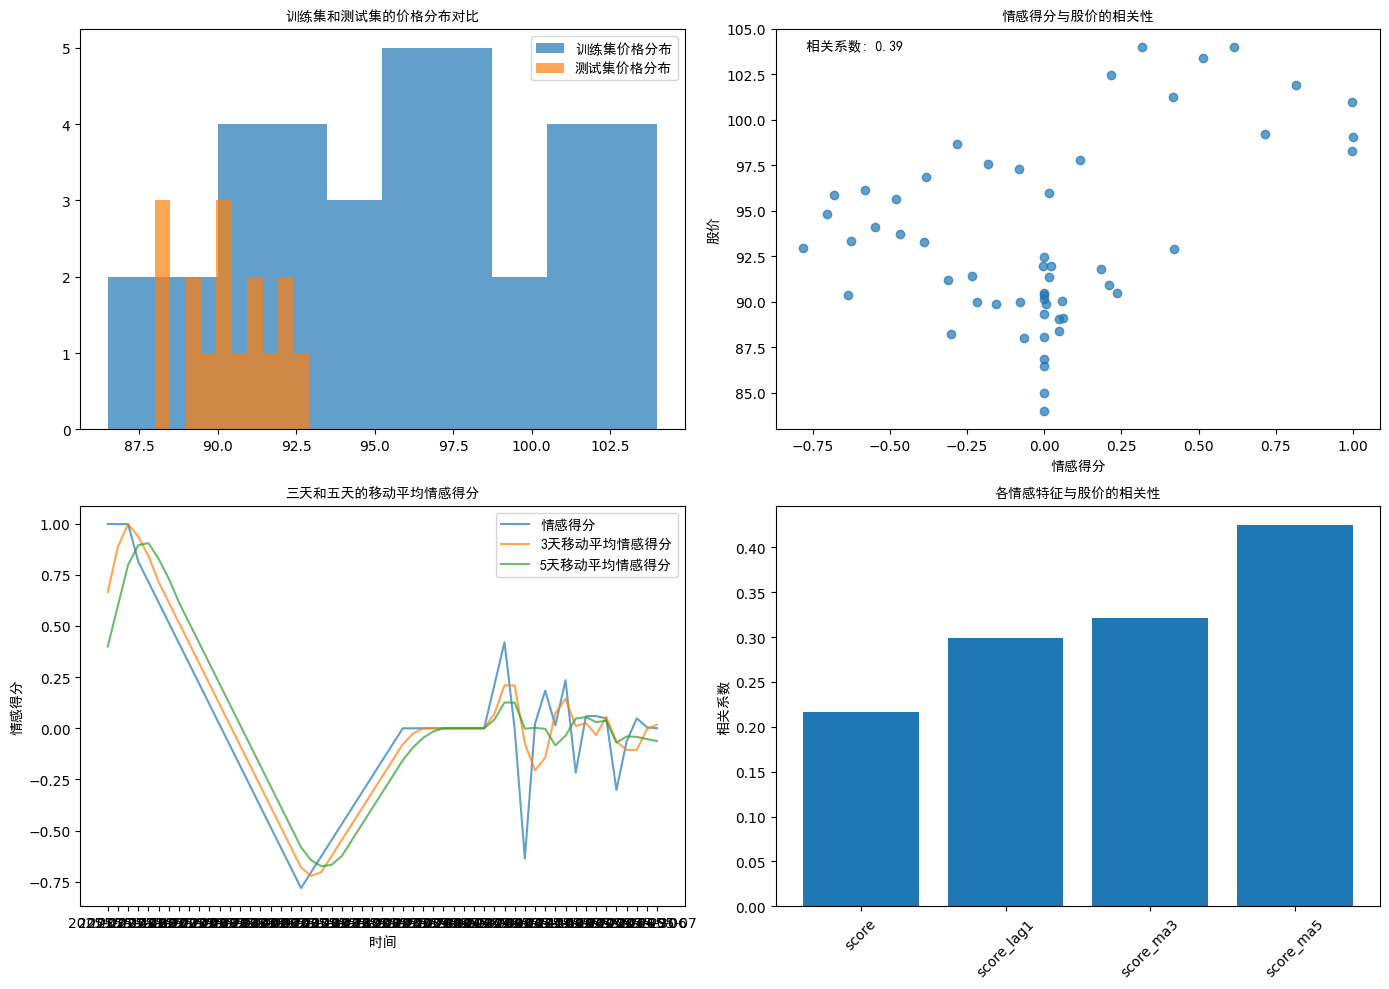


可能的原因分析:
1. 测试集波动性较低: 如果测试集的股价波动较小或趋势更明显，模型可能更容易预测
2. 情感分析特征与股价相关性不足: 情感可能与股价关联不强或滞后效应明显
3. 特征工程问题: 情感特征的提取方式可能不理想，加入噪声大于有用信号
4. 模型复杂度: 加入更多特征增加了模型复杂度，可能导致过拟合
5. 数据量限制: 训练数据可能不足以让模型学习情感与股价的复杂关系

改进建议:
1. 尝试不同的情感特征处理方式，如不同时间窗口的加权平均
2. 考虑情感数据的滞后效应，尝试不同的时间滞后
3. 使用特征选择方法筛选最有效的特征
4. 增加正则化或使用更简单的模型结构
5. 增加训练数据量，尤其是涵盖不同市场状态的数据


In [ ]:
# 分析预测性能问题

# 1. 观察训练集和测试集的RMSE差异
print(f"训练集RMSE: {trainScore:.2f} vs 测试集RMSE: {testScore:.2f}")
print(f"测试集比训练集性能提升了: {(trainScore - testScore) / trainScore * 100:.2f}%")

# 2. 分析原因
plt.figure(figsize=(14, 10))

# 2.1 比较测试集和训练集的原始数据分布
plt.subplot(2, 2, 1)
plt.hist(trainY, bins=10, alpha=0.7, label='训练集价格分布')
plt.hist(testY, bins=10, alpha=0.7, label='测试集价格分布')
plt.title('训练集和测试集的价格分布对比', fontproperties=font)
plt.legend(prop=font)

# 2.2 比较情感得分与股价的相关性
plt.subplot(2, 2, 2)
plt.scatter(merged_data['score'], merged_data['close'], alpha=0.7)
plt.title('情感得分与股价的相关性', fontproperties=font)
plt.xlabel('情感得分', fontproperties=font)
plt.ylabel('股价', fontproperties=font)
correlation = merged_data['score'].corr(merged_data['close'])
plt.annotate(f'相关系数: {correlation:.2f}', xy=(0.05, 0.95), 
             xycoords='axes fraction', fontproperties=font)

# # 2.3 三天和五天的移动平均情感得分观察
plt.subplot(2, 2, 3)
plt.plot(merged_data['score'], label='情感得分', alpha=0.7)
plt.plot(merged_data['score_ma3'], label='3天移动平均情感得分', alpha=0.7)
plt.plot(merged_data['score_ma5'], label='5天移动平均情感得分', alpha=0.7)
plt.title('三天和五天的移动平均情感得分', fontproperties=font)
plt.xlabel('时间', fontproperties=font)
plt.ylabel('情感得分', fontproperties=font)
plt.legend(prop=font)

# 2.4 检查情感特征的预测能力
plt.subplot(2, 2, 4)

# 创建情感特征
merged_data_copy = merged_data.copy()
merged_data_copy['score_lag1'] = merged_data_copy['score'].shift(1)  # 前一天的情感得分
merged_data_copy['score_ma3'] = merged_data_copy['score'].rolling(window=3).mean()  # 3天移动平均
merged_data_copy['score_ma5'] = merged_data_copy['score'].rolling(window=5).mean()  # 5天移动平均

# 删除NaN值以便计算相关性
merged_data_clean = merged_data_copy.dropna()

sentiment_features = ['score', 'score_lag1', 'score_ma3', 'score_ma5']
correlations = [merged_data_clean['close'].corr(merged_data_clean[feat]) for feat in sentiment_features]
plt.bar(sentiment_features, correlations)
plt.title('各情感特征与股价的相关性', fontproperties=font)
plt.ylabel('相关系数', fontproperties=font)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
